### Lab 10: Machine Breakdown and Maintenance: Simulate a manufacturing workshop containing 5 identical
machines. The time between breakdowns is exponentially distributed, and repair times follow a Weibull
distribution. Calculate machine downtime and overall system throughput.

   Machine Breakdown & Maintenance Simulation
  Machine 1: Downtime = 223.54 hrs | Breakdowns =  85 | Availability = 77.6%
  Machine 2: Downtime = 232.86 hrs | Breakdowns =  80 | Availability = 76.7%
  Machine 3: Downtime = 175.97 hrs | Breakdowns =  72 | Availability = 82.4%
  Machine 4: Downtime = 199.61 hrs | Breakdowns =  71 | Availability = 80.0%
  Machine 5: Downtime = 291.46 hrs | Breakdowns =  96 | Availability = 70.9%
--------------------------------------------------
  Total Downtime  (all machines) : 1123.44 hrs
  Total Breakdowns (all machines): 404
  Avg Downtime per Machine       : 224.69 hrs
  System Throughput (repairs done): 404


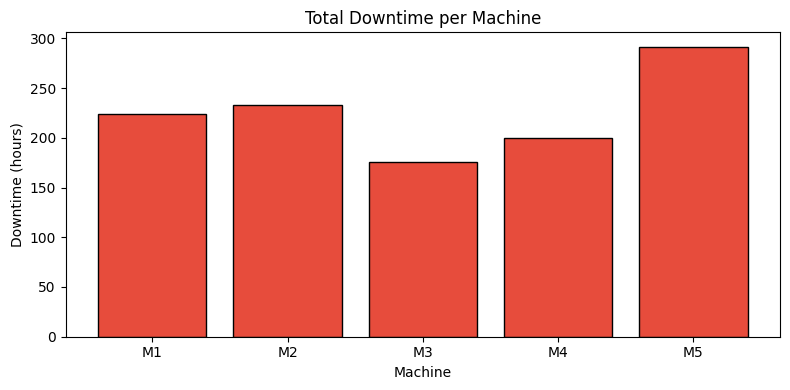

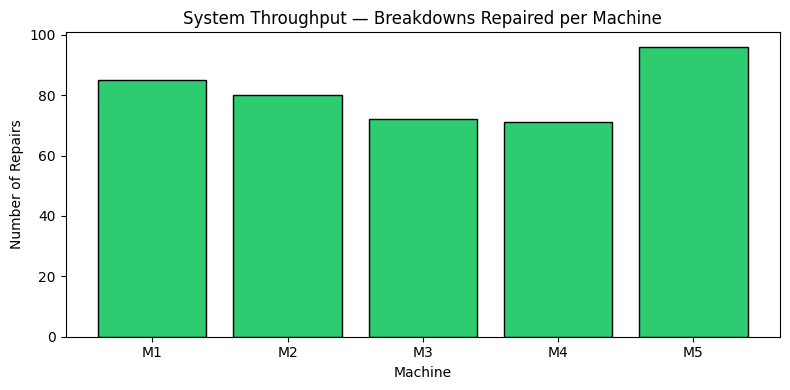

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_machines    = 5
sim_time      = 1000        # total simulation time (hours)
lam           = 0.1         # breakdown rate → mean time between breakdowns = 1/λ = 10 hrs
weibull_shape = 1.5         # shape (k) for repair time
weibull_scale = 3.0         # scale (λ) for repair time → mean repair ≈ scale * Γ(1 + 1/shape)

total_downtime   = []
total_throughput = []

for m in range(n_machines):
    downtime   = 0
    time       = 0
    throughput = 0

    while time < sim_time:
        time_to_breakdown = np.random.exponential(1 / lam)
        time += time_to_breakdown

        if time >= sim_time:
            break

        # Repair time (Weibull)
        repair_time = weibull_scale * np.random.weibull(weibull_shape)
        downtime   += repair_time
        time       += repair_time
        throughput += 1      # one breakdown-repair cycle completed

    total_downtime.append(round(downtime, 2))
    total_throughput.append(throughput)

# Results
print("=" * 50)
print("   Machine Breakdown & Maintenance Simulation")
print("=" * 50)
for i in range(n_machines):
    uptime = sim_time - total_downtime[i]
    avail  = (uptime / sim_time) * 100
    print(f"  Machine {i+1}: Downtime = {total_downtime[i]:6.2f} hrs | "
          f"Breakdowns = {total_throughput[i]:3d} | Availability = {avail:.1f}%")

print("-" * 50)
print(f"  Total Downtime  (all machines) : {sum(total_downtime):.2f} hrs")
print(f"  Total Breakdowns (all machines): {sum(total_throughput)}")
print(f"  Avg Downtime per Machine       : {np.mean(total_downtime):.2f} hrs")
print(f"  System Throughput (repairs done): {sum(total_throughput)}")
print("=" * 50)

# Plot 1: Downtime per machine
plt.figure(figsize=(8, 4))
plt.bar([f"M{i+1}" for i in range(n_machines)], total_downtime,
        color='#e74c3c', edgecolor='black')
plt.title("Total Downtime per Machine")
plt.xlabel("Machine")
plt.ylabel("Downtime (hours)")
plt.tight_layout()
plt.show()

# Plot 2: Throughput (breakdowns repaired) per machine
plt.figure(figsize=(8, 4))
plt.bar([f"M{i+1}" for i in range(n_machines)], total_throughput,
        color='#2ecc71', edgecolor='black')
plt.title("System Throughput — Breakdowns Repaired per Machine")
plt.xlabel("Machine")
plt.ylabel("Number of Repairs")
plt.tight_layout()
plt.show()